# Analyze uncertainty for MgkPro against Loop 3

Same MgkPro/EryPro uncertainty analysis as analyze_and_plot_uncertainty_mgk.ipynb, compared against Loop 3.

In [44]:
from pathlib import Path
import copy
import math
import os
import sys

import fpsample
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sp
import seaborn as sns
import yaml
from matplotlib.colors import Normalize
from matplotlib.pyplot import rc_context
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.spatial.distance import pdist
from tqdm import tqdm

sys.path.insert(0, "../../../../../../shared_utils")
from experiment_utils import manual_filtering

## Initialize columns to keep 

In [2]:
# Cell type fractions
celltype_fraction = {
    "late_MgkPro": 0.05, 
    "EryPro_prop": 0.03
}

columns_of_interest = [
    'gm-csf_[ng_ml]',
     'tpo_[ng_ml]',
     'sr1_[nm]',
     'um171_[nm]',
     'um729_[µm]',
     'scf_[ng_ml]',
     'butyzamide_[nm]',
     'retinoic_acid_[µm]',
     'ldl_[ng_ml]',
     'il3_[ng_ml]',
     'o2_[%]',
     'days_of_culture',
     'run_name',
     "cfg:constraints:c_scheduler_kwargs:t_warmup",
     "cfg:constraints:c_scheduler_kwargs:vmin",
     "cfg:constraints:c_scheduler_kwargs:vmax",

]

columns_of_interest_l4 =  columns_of_interest + ["il7_[ng_ml]",
                                                 "mcsf_[ng_ml]",
                                                 "ly_cocktail_[ul/well]", 
                                                 "loss", 
                                                 "target_ct_loss_std",
                                                 "target_ct_loss_mean",
                                                 "ct_prop_total_variance"]

## Load solutions 

In [3]:
def load_pure_cell_type_solutions(
    path_to_results,
    paths,
    cell_types,
    load_uncertainties=True
):

    path_to_results = Path(path_to_results)

    pure_cell_type_solution_dict = {
        cell_type: [] for cell_type in cell_types
    }

    for experiment_folder in tqdm(paths):

        cell_type_file_paths = path_to_results / experiment_folder

        if not cell_type_file_paths.exists():
            continue

        # Iterate through cell types
        for cell_type in os.listdir(cell_type_file_paths):

            if cell_type not in cell_types:
                continue

            config_exp_folders = cell_type_file_paths / cell_type

            if not config_exp_folders.is_dir():
                continue

            # Iterate through experiment configs
            for config_exp_folder in os.listdir(config_exp_folders):

                exp_folder = config_exp_folders / config_exp_folder

                if not exp_folder.is_dir():
                    continue

                # Check candidates.csv exists
                if "candidates.csv" not in os.listdir(exp_folder):
                    continue

                if load_uncertainties:
                    uncertainty_path = (
                        exp_folder
                        / "uncertainty_annotation"
                        / "candidates_with_uncertainties.csv"
                    )

                else:
                    uncertainty_path = (
                        exp_folder
                        / "candidates.csv"
                    )

                # Check uncertainty annotation exists
                if uncertainty_path.exists():
 
                    candidate_with_uncertainty_df = pd.read_csv(
                        uncertainty_path
                    )

                    candidate_with_uncertainty_df["run_name"] = [
                        Path(file).name
                        for file in candidate_with_uncertainty_df[
                            "cfg:paths:dump_dir"
                        ]
                    ]

                    pure_cell_type_solution_dict[cell_type].append(
                        candidate_with_uncertainty_df
                    )

    return pure_cell_type_solution_dict

## Read annotation file

In [4]:
# Read annotation files
ANNOTATION_CFG_FILE = "../../../../../../inverse/loss_guidance/config/annotation/default.yaml"
with open(ANNOTATION_CFG_FILE, "r") as fb:
    annotation_cfg = yaml.safe_load(fb)
protocol_cols = annotation_cfg["protocol_columns"]
protocol_cols_l4 = protocol_cols + ['il7_[ng_ml]','mcsf_[ng_ml]','ly_cocktail_[ul/well]']

# Read constraint files
ANNOTATION_CFG_FILE_BOUNDS = "../../../../../../inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound = yaml.safe_load(fb)
ubound_dict, lbound_dict = annotation_cfg_bound["ubound_dict"],  annotation_cfg_bound["lbound_dict"]

ANNOTATION_CFG_FILE_BOUNDS = "<INSERT PATH TO default_all_cols_loop4.yaml>"  # TODO: not found under inverse/loss_guidance/config/constraints/ - set to your own path
with open(ANNOTATION_CFG_FILE_BOUNDS, "r") as fb:
    annotation_cfg_bound_l4 = yaml.safe_load(fb)
ubound_dict_l4, lbound_dict_l4 = annotation_cfg_bound_l4["ubound_dict"],  annotation_cfg_bound_l4["lbound_dict"]

# Collect per parameter bounds 
bounds = {}
for param in lbound_dict:
    bounds[param] = (lbound_dict[param], ubound_dict[param])

bounds_l4 = {}
for param in lbound_dict_l4:
    bounds_l4[param] = (lbound_dict_l4[param], ubound_dict_l4[param])

### Collect optimized samples 

In [5]:
path_to_results_loop4 = Path("../../../../../../project_folder/output/inverse/loss_guidance/loop3_replicate")
paths_loop4 = os.listdir(path_to_results_loop4)

path_to_results_loop2 = Path("../../../../../../project_folder/output/inverse/loss_guidance/loop2p5_replicate_old_clf")
paths_loop2 = os.listdir(path_to_results_loop2)

In [6]:
cell_types = ["late_MgkPro"]

raw_solutions_loop4 = load_pure_cell_type_solutions(
    path_to_results_loop4,
    paths_loop4,
    cell_types,
    load_uncertainties=True
)

raw_solutions_loop2 = load_pure_cell_type_solutions(
    path_to_results_loop2,
    paths_loop2,
    cell_types,
    load_uncertainties=False
)

100%|██████████| 6/6 [00:04<00:00,  1.22it/s]


In [7]:
raw_solutions_loop4 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop4.items()
}

raw_solutions_loop2 = {
    key: pd.concat(val, axis=0) for key, val in raw_solutions_loop2.items()
}

In [8]:
mgkpro_l2 = raw_solutions_loop2['late_MgkPro']
mgkpro_l4 = raw_solutions_loop4['late_MgkPro']

mgkpro_l2 = mgkpro_l2.reset_index()
mgkpro_l4 = mgkpro_l4.reset_index()

In [9]:
for col in mgkpro_l4.columns:
    print(col)

index
Unnamed: 0
sample_id
gm-csf_[ng_ml]
tpo_[ng_ml]
sr1_[nm]
um171_[nm]
um729_[µm]
scf_[ng_ml]
butyzamide_[nm]
retinoic_acid_[µm]
ldl_[ng_ml]
il3_[ng_ml]
o2_[%]
days_of_culture
il7_[ng_ml]
mcsf_[ng_ml]
ly_cocktail_[ul/well]
gm-csf_[ng_ml]:rescaled
tpo_[ng_ml]:rescaled
sr1_[nm]:rescaled
um171_[nm]:rescaled
um729_[µm]:rescaled
scf_[ng_ml]:rescaled
butyzamide_[nm]:rescaled
retinoic_acid_[µm]:rescaled
ldl_[ng_ml]:rescaled
il3_[ng_ml]:rescaled
o2_[%]:rescaled
days_of_culture:rescaled
il7_[ng_ml]:rescaled
mcsf_[ng_ml]:rescaled
ly_cocktail_[ul/well]:rescaled
loss
CD14Mono_prop
CD16Mono_prop
CyclingPro1_prop
CyclingPro2_prop
Early_GMP_prop
EosBasMast1_prop
EosBasMast2_prop
EosBasMast3_prop
EryPro_prop
GMP-Neutro_prop
GMP_cycling_prop
HSCs_prop
LMPP-CLP_prop
MLP_prop
MPP_prop
MPP_MgkEry_prop
MgKEryPro1_prop
MgKEryPro2_prop
ProB_prop
earlyMPP_prop
late_MgkPro_prop
preProB_prop
pre_cDC1_prop
pre_cDC2_prop
cfg:annotation:protocol_columns
cfg:annotation:protocol_obs_key_added
cfg:annotation:proto

# Filter solutions

In [10]:
# Collect filtered and annotated data frames 
filtered_df_mgkpro_l4, annotated_df_mgkpro_l4 = manual_filtering(
    df_dict={"late_MgkPro": mgkpro_l4},
    bounds=bounds_l4,
    columns_to_keep=columns_of_interest_l4, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=1, 
    protocol_cols=protocol_cols_l4,
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=False
)
mgkpro_l4 = filtered_df_mgkpro_l4["late_MgkPro"]

# Collect filtered and annotated data frames 
filtered_df_mgkpro_l2, annotated_df_mgkpro_l2 = manual_filtering(
    df_dict={"late_MgkPro": mgkpro_l2},
    bounds=bounds,
    columns_to_keep=columns_of_interest, 
    celltype_fraction=celltype_fraction,
    margin_frac_bounds=0, 
    protocol_cols=protocol_cols, 
    use_fraction_filter=True, 
    use_oxygen_days_filter=True,
    use_bounds_filter=True
)
mgkpro_l2 = filtered_df_mgkpro_l2["late_MgkPro"]

## Check amount of TPO in generations 

In [11]:
to_plot_tpo_size_mgk = {"dataset_type": ["L2", "L4"], 
                       "Max. predicted TPO": [mgkpro_l2["tpo_[ng_ml]"].max(), mgkpro_l4["tpo_[ng_ml]"].max()]}

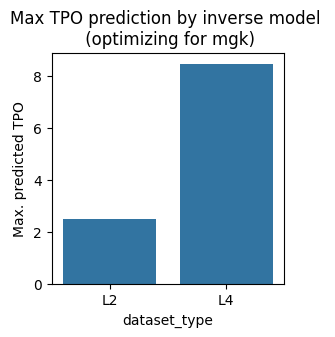

In [12]:
plt.figure(figsize=(3,3))
sns.barplot(to_plot_tpo_size_mgk, x="dataset_type", y="Max. predicted TPO")
plt.title("Max TPO prediction by inverse model \n (optimizing for mgk)")
plt.show()

## Plot PCAs

In [13]:
# # Set global figure params — dpi_save controls resolution of saved files specifically
# sc.set_figure_params(dpi=500, dpi_save=500, figsize=(3, 3))

# # Optional: set output directory (defaults to ./figures/)
# sc.settings.figdir = "./plots"

# # mgkpro_l2_filtered = mgkpro_l2[mgkpro_l2["late_MgkPro_prop"] > 0.10]
# X_l2 = mgkpro_l2.loc[:, protocol_cols].values
# adata_l2 = sc.AnnData(X=X_l2.copy(), obs=mgkpro_l2)
# sc.pp.log1p(adata_l2)
# sc.pp.pca(adata_l2)


# sc.pl.pca(adata_l2, s=200, color="butyzamide_[nm]", vmax=100, frameon=False,
#           cmap="plasma", save="_butyzamide.png")
# sc.pl.pca(adata_l2, s=200, color="tpo_[ng_ml]", vmax=3, frameon=False,
#           cmap="plasma", save="_tpo.png")
# sc.pl.pca(adata_l2, s=200, color="late_MgkPro_prop", frameon=False,
#           cmap="plasma", save="_late_mgkpro_prop.png", vmin=0, vmax=1)

# sc.set_figure_params(dpi=80, dpi_save=80, figsize=(3, 3))

## Check heatmaps

In [14]:
mgkpro_prot = np.log1p(mgkpro_l4.loc[:, protocol_cols_l4])
late_mgkpro_prop = mgkpro_l4["late_MgkPro_prop"]

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


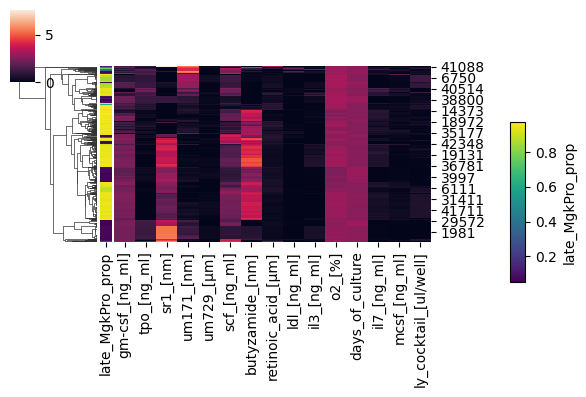

In [15]:
# Map the proportion values to colors using a continuous colormap
norm = Normalize(vmin=late_mgkpro_prop.min(), vmax=late_mgkpro_prop.max())
cmap = cm.viridis  # choose any colormap you like, e.g. "coolwarm", "magma"
row_colors = late_mgkpro_prop.map(lambda x: cmap(norm(x)))

g = sns.clustermap(
    mgkpro_prot,
    row_cluster=True,
    col_cluster=False,
    row_colors=row_colors,
    figsize=(5, 4),
)

# Add a separate colorbar legend for the row_colors annotation
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar_ax = g.fig.add_axes([1.02, 0.3, 0.03, 0.4])  # [left, bottom, width, height]
g.fig.colorbar(sm, cax=cbar_ax, label="late_MgkPro_prop")

plt.show()

## Check uncertainties

<Axes: xlabel='late_MgkPro_prop', ylabel='target_ct_loss_std'>

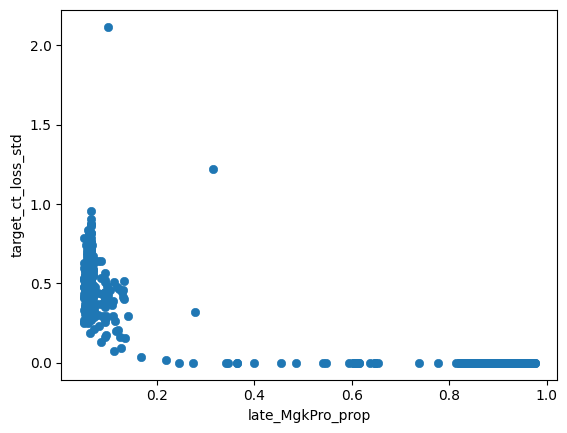

In [16]:
sns.scatterplot(mgkpro_l4, 
               x="late_MgkPro_prop", 
               y="target_ct_loss_std", 
               edgecolor=None)

In [17]:
# 1. Get the linkage used for the row dendrogram
row_linkage = g.dendrogram_row.linkage

# 2. Cut the tree into k clusters (tune this by eye from the dendrogram)
n_clusters = 5
row_clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')

# 3. Build a dataframe linking each row (sample) to its cluster + its proportion value
cluster_df = pd.DataFrame({
    'cluster': row_clusters,
    'late_MgkPro_prop': late_mgkpro_prop.values
}, index=mgkpro_prot.index)

# 4. Check which cluster(s) have the highest average proportion
cluster_summary = cluster_df.groupby('cluster')['late_MgkPro_prop'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print(cluster_summary)

# 5. Pull out the actual samples in the top cluster(s)
top_cluster_id = cluster_summary.index[0]
high_prop_samples = cluster_df[cluster_df['cluster'] == top_cluster_id]
print(high_prop_samples)

             mean  count
cluster                 
3        0.786205    579
2        0.645643    222
5        0.486223      1
1        0.128233      5
4        0.086236    112
       cluster  late_MgkPro_prop
18240        3          0.973366
36548        3          0.969329
19727        3          0.968883
11048        3          0.968560
33317        3          0.967871
...        ...               ...
10247        3          0.051228
34897        3          0.051217
16547        3          0.050894
16847        3          0.050489
4697         3          0.050004

[579 rows x 2 columns]


In [18]:
cluster_df

,cluster,late_MgkPro_prop
14850,2,0.976021
11050,2,0.975834
18240,3,0.973366
10900,2,0.973257
10250,2,0.972872
...,...,...
26872,4,0.050613
16847,3,0.050489
27372,4,0.050181
29572,4,0.050178


Check if clusters are the ones we think

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


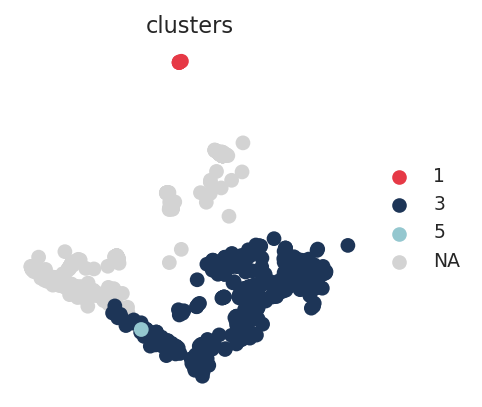

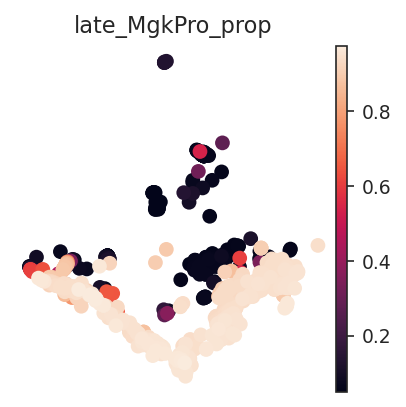

In [46]:
with plt.rc_context({"figure.figsize": (3, 3), "figure.dpi": 150}):
    X_l4 = mgkpro_prot.values
    adata_l4 = sc.AnnData(X=X_l4.copy(), obs=mgkpro_l4)
    adata_l4.obs["clusters"] = row_clusters
    adata_l4.obs["clusters"] = adata_l4.obs["clusters"].astype("category")

    sc.pp.pca(adata_l4)

    # Make sure the palette keys match the actual category dtype (str vs int)
    cluster_palette = {
        1: "#E63946",
        3: "#1D3557",
        5: "#94C7CF",
    }
    cats = adata_l4.obs["clusters"].cat.categories
    if cats.dtype == object or all(isinstance(c, str) for c in cats):
        cluster_palette = {str(k): v for k, v in cluster_palette.items()}

    # Give every category a color so scanpy's internal palette build doesn't KeyError
    all_colors = {c: "#CCCCCC" for c in cats}  # fallback grey for other clusters
    all_colors.update(cluster_palette)

    sc.pl.pca(
        adata_l4,
        s=200,
        color="clusters",
        frameon=False,
        groups=list(cluster_palette.keys()),
        palette=all_colors,
    )

    sc.pl.pca(adata_l4, s=200, color="late_MgkPro_prop", frameon=False)